Model initialized on cuda


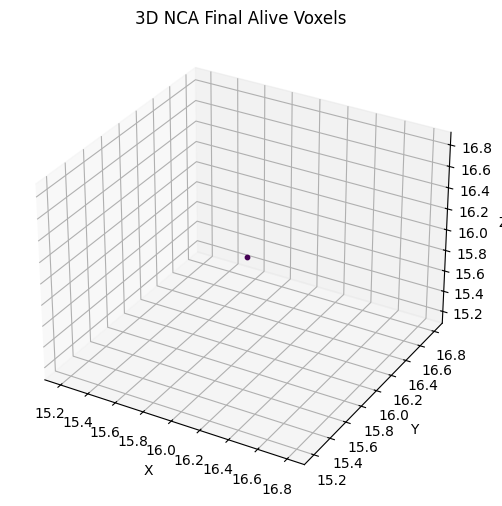

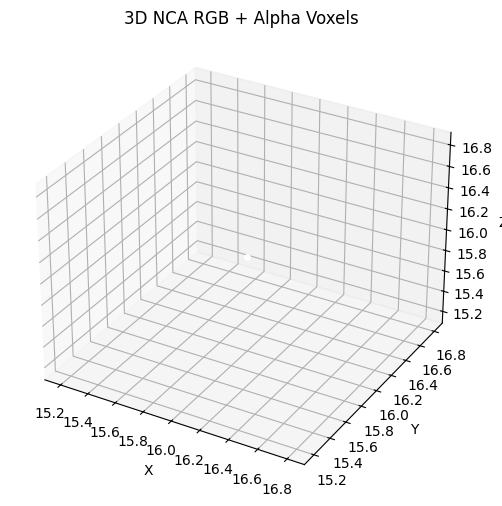

In [ ]:
# --- 0. Setup path so imports work ---
import sys, os
sys.path.append(os.path.abspath("../src"))

# --- 1. Imports ---
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Import your modules
from core.cell import CellConfig
from core.perception import PerceptionConfig
from core.update import UpdateConfig
from core.grid import Grid3D, GridConfig

# --- 2. Configuration ---
device = "cuda" if torch.cuda.is_available() else "cpu"

cell_cfg = CellConfig(hidden_channels=16, visible_channels=4)
perc_cfg = PerceptionConfig(kernel_radius=1, channel_groups=3)
upd_cfg = UpdateConfig(hidden_dim=64, stochastic_update=True, fire_rate=0.5)
grid_cfg = GridConfig(size=(32, 32, 32))

# --- 3. Initialize model ---
model = Grid3D(cell_cfg, perc_cfg, upd_cfg, grid_cfg).to(device)
print("Model initialized on", device)

# --- 4. Create initial state and run evolution ---
state = model.seed_center(batch_size=1, device=device)
with torch.no_grad():
    final_state = model(state, steps=32)

# --- 5. Extract visible alpha channel ---
alpha = final_state[0, -1].cpu().numpy()

# --- 6. Simple 3D voxel visualization ---
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

threshold = 0.1
xs, ys, zs = (alpha > threshold).nonzero()

ax.scatter(xs, ys, zs, c=alpha[alpha > threshold], cmap="viridis", s=10)
ax.set_title("3D NCA Final Alive Voxels")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

